In [1]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
import time

u = unit(coerce_to_integer=True)

2026-06-08 17:18:02,678 - qm - INFO     - Starting session: f342a348-3568-4e87-b79a-00870830ec63


In [28]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.24 * u.us,
    pulse_amplitude=0.47,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=142.7,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=17300 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "floquet_expt"
)

cfg = qnmr.cfg_from_settings(settings)

In [ ]:
t0 = 5.0 * u.us
# u0=1; v=0; w=0 # DQ Hamiltonian
u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
a=0; b=0; c=0
c2 = .05
u0*=c2; v*=c2; w*=c2

print(f"",(u0-w),"SxSx + ",(v-u0),"SySy + ",(w-v),"SzSz")
p1 = settings.pulse_length
t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
t1e = t1 + (p1/2) # starting and ending t1 accounts for p1 subtraction below

# Pine-8 sequence pattern for engineering H=0
wei16_phases = np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                         t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
print(wei16_delays)
print(t1, t2, t3, t1p, t2p, t3p)

total=0
print("Total sequence time: ", np.sum(wei16_delays))

 -0.025 SxSx +  -0.025 SySy +  0.05 SzSz
[4630. 3635. 8510. 3635. 9260. 3635. 8510. 3635. 9260. 3635. 8510. 3635.
 9260. 3635. 8510. 3635. 4630.]
5249.999999999999 4875.0 4875.0 5249.999999999999 4875.0 4875.0
Total sequence time:  100160.0


Testing c2=-0.025 now.
4733.8494314 5155.37471909 5111.60629594 4733.28251133 5157.88129102 5108.00575121
2026-06-08 17:51:16,709 - qm - INFO     - Performing health check
2026-06-08 17:51:16,724 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 17:51:17,647 - qm - INFO     - Clearing queue
2026-06-08 17:51:17,655 - qm - INFO     - Adding program to queue.


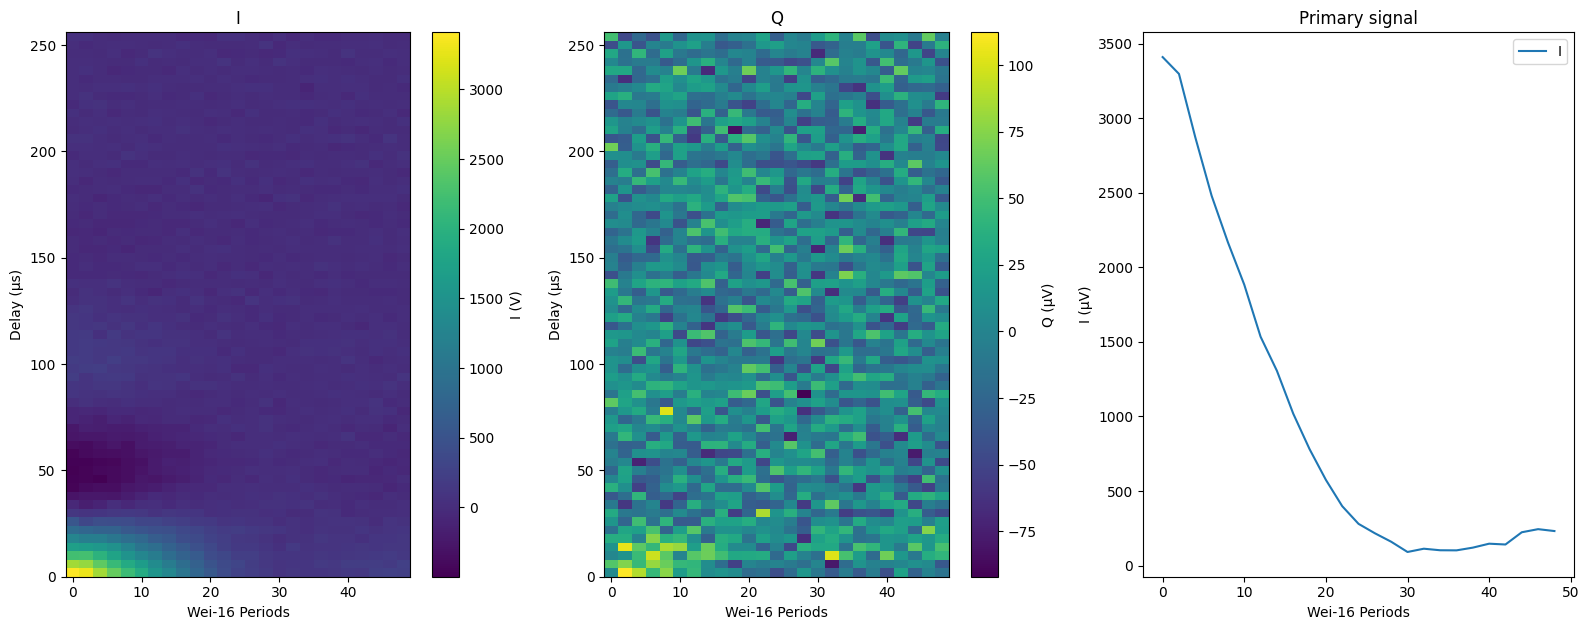

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.26s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.79s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.30s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0059
Experiment with c2=-0.025 complete!



Testing c2=-0.02 now.
4781.72295941 5132.24122359 5087.9152078 4785.86790744 5130.22648367 5082.02621808
2026-06-08 17:57:58,236 - qm - INFO     - Performing health check
2026-06-08 17:57:58,236 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 17:57:58,877 - qm - INFO     - Clearing queue
2026-06-08 17:57:58,877 - qm - INFO     - Adding program to queue.


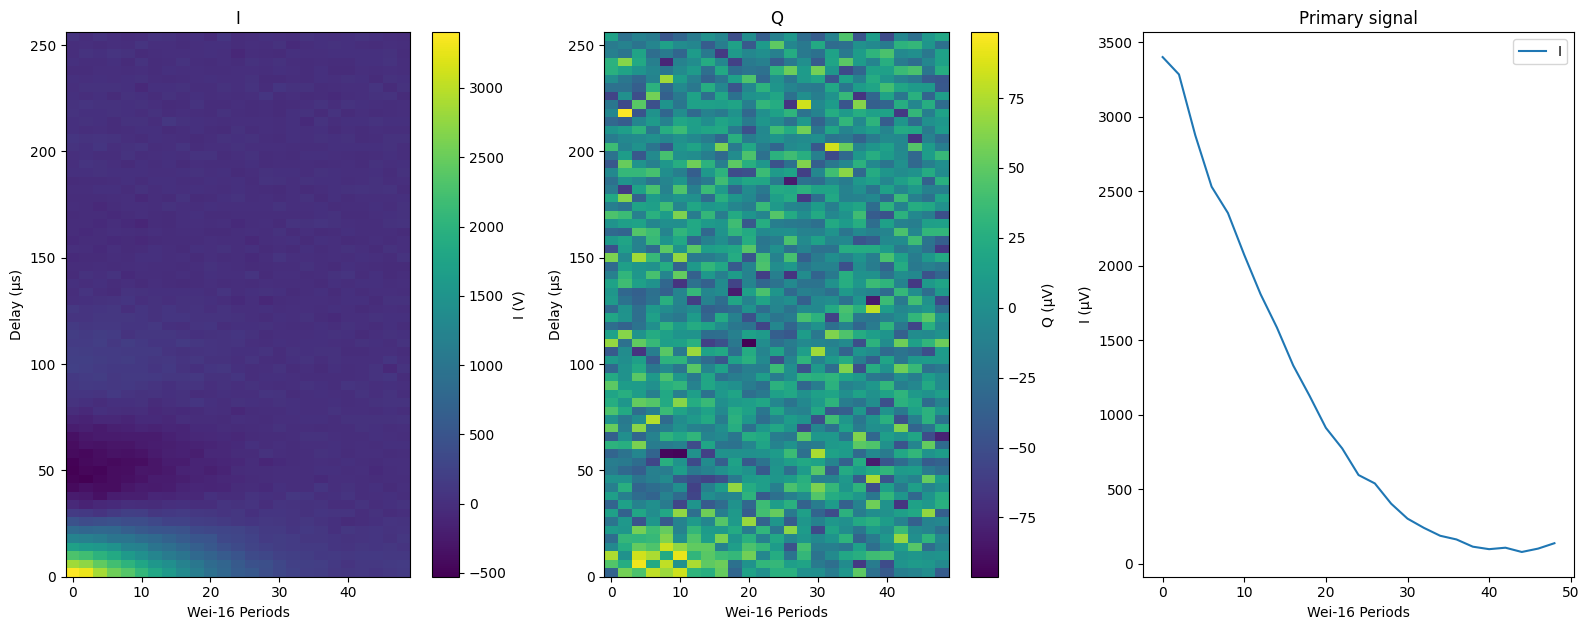

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.66s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.14s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0060
Experiment with c2=-0.02 complete!



Testing c2=-0.015 now.
4834.44272209 5106.44489723 5060.56232846 4833.91766161 5104.9902268 5059.6421638
2026-06-08 18:04:38,766 - qm - INFO     - Performing health check
2026-06-08 18:04:38,782 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:04:39,438 - qm - INFO     - Clearing queue
2026-06-08 18:04:39,454 - qm - INFO     - Adding program to queue.


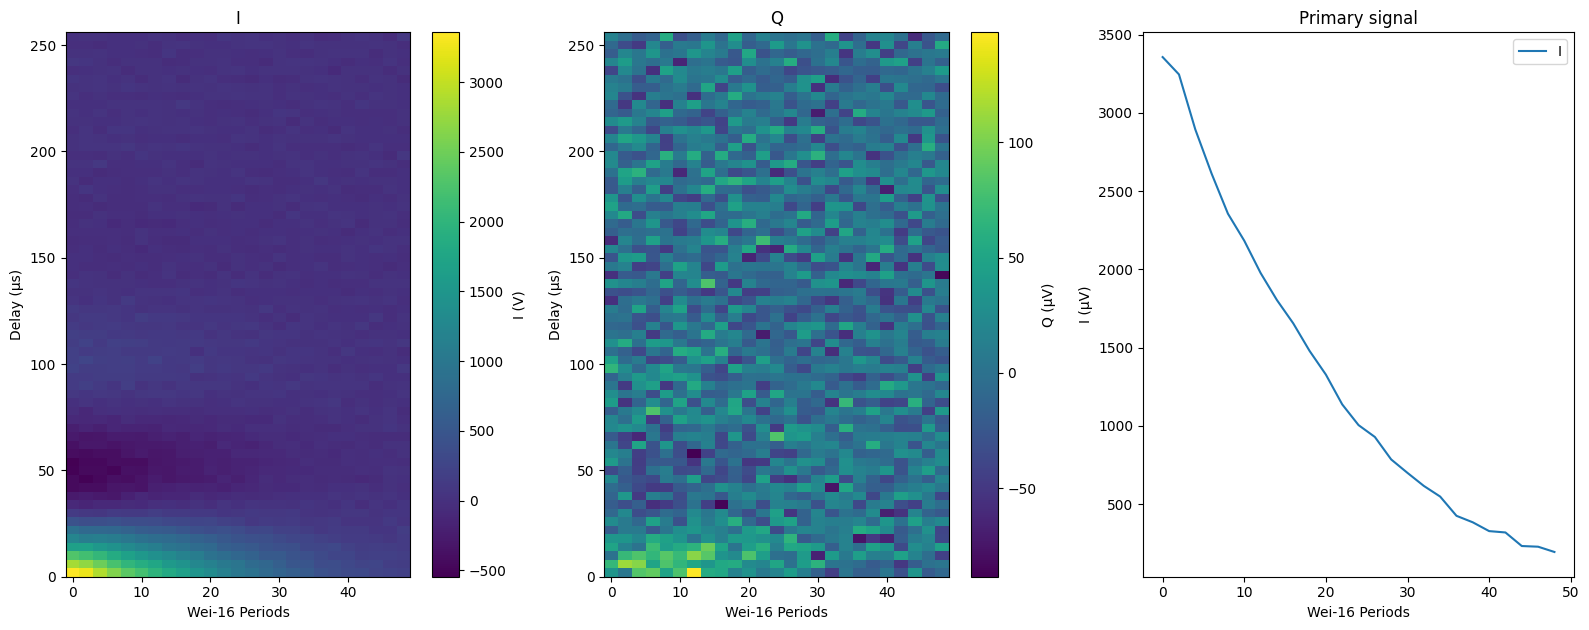

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.70s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.22s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0061
Experiment with c2=-0.015 complete!



Testing c2=-0.01 now.
4882.29296006 5076.19341604 5029.13783319 4887.14815252 5084.30108528 5040.92655291
2026-06-08 18:11:19,516 - qm - INFO     - Performing health check
2026-06-08 18:11:19,516 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:11:20,209 - qm - INFO     - Clearing queue
2026-06-08 18:11:20,209 - qm - INFO     - Adding program to queue.


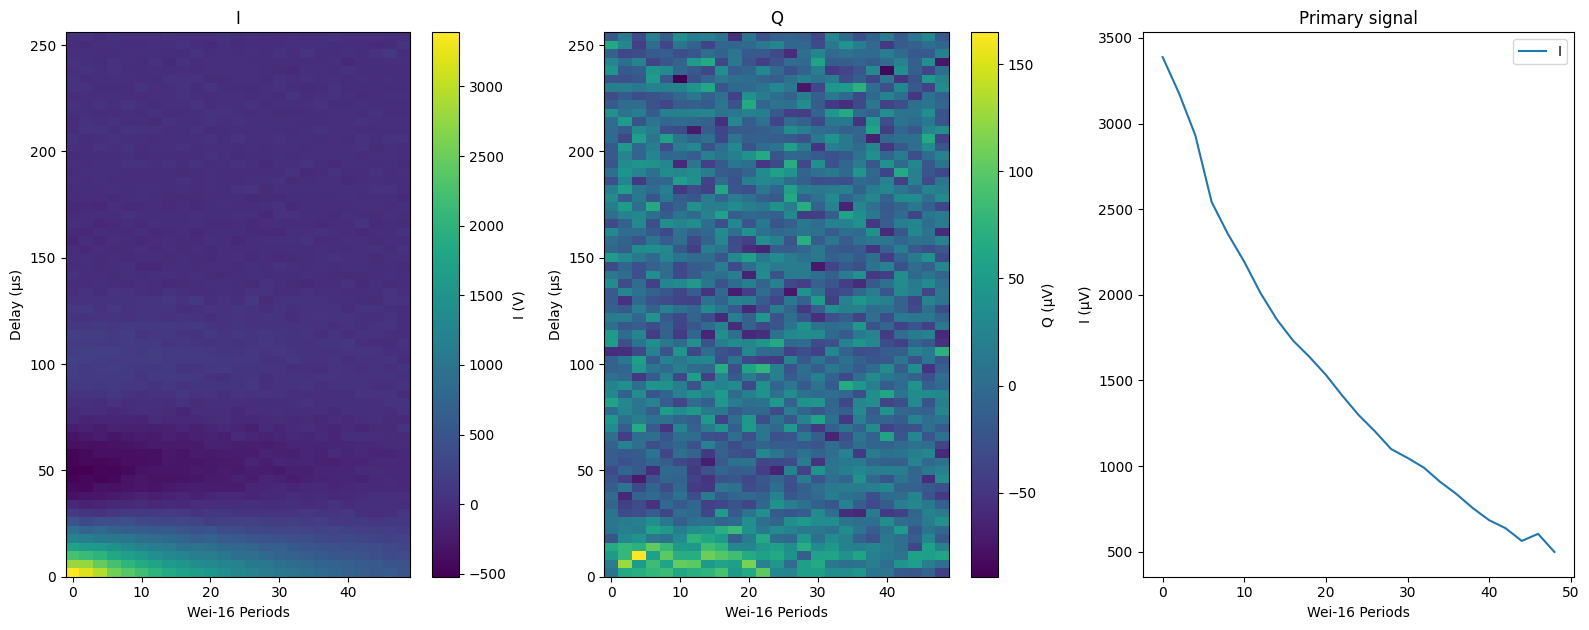

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.30s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.82s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.34s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0062
Experiment with c2=-0.01 complete!



Testing c2=-0.005 now.
4926.3360118 5054.4866408 5010.67447744 4942.86759649 5055.40091762 5010.23435585
2026-06-08 18:18:00,469 - qm - INFO     - Performing health check
2026-06-08 18:18:00,469 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:18:01,282 - qm - INFO     - Clearing queue
2026-06-08 18:18:01,299 - qm - INFO     - Adding program to queue.


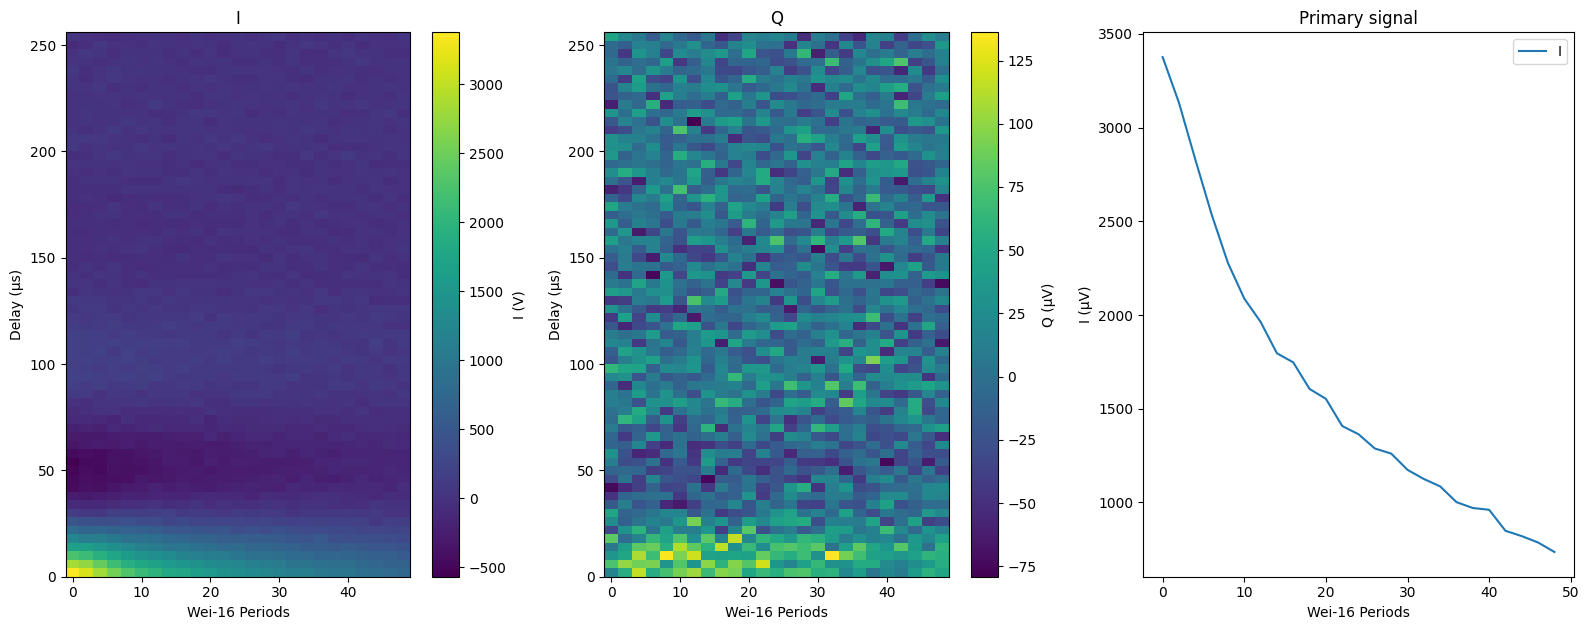

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.28s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.80s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.28s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0063
Experiment with c2=-0.005 complete!



Testing c2=0 now.
4976.2371799 5029.73319242 4983.82085345 4993.31674266 5029.36891249 4987.52311908
2026-06-08 18:24:41,297 - qm - INFO     - Performing health check
2026-06-08 18:24:41,297 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:24:41,989 - qm - INFO     - Clearing queue
2026-06-08 18:24:41,989 - qm - INFO     - Adding program to queue.


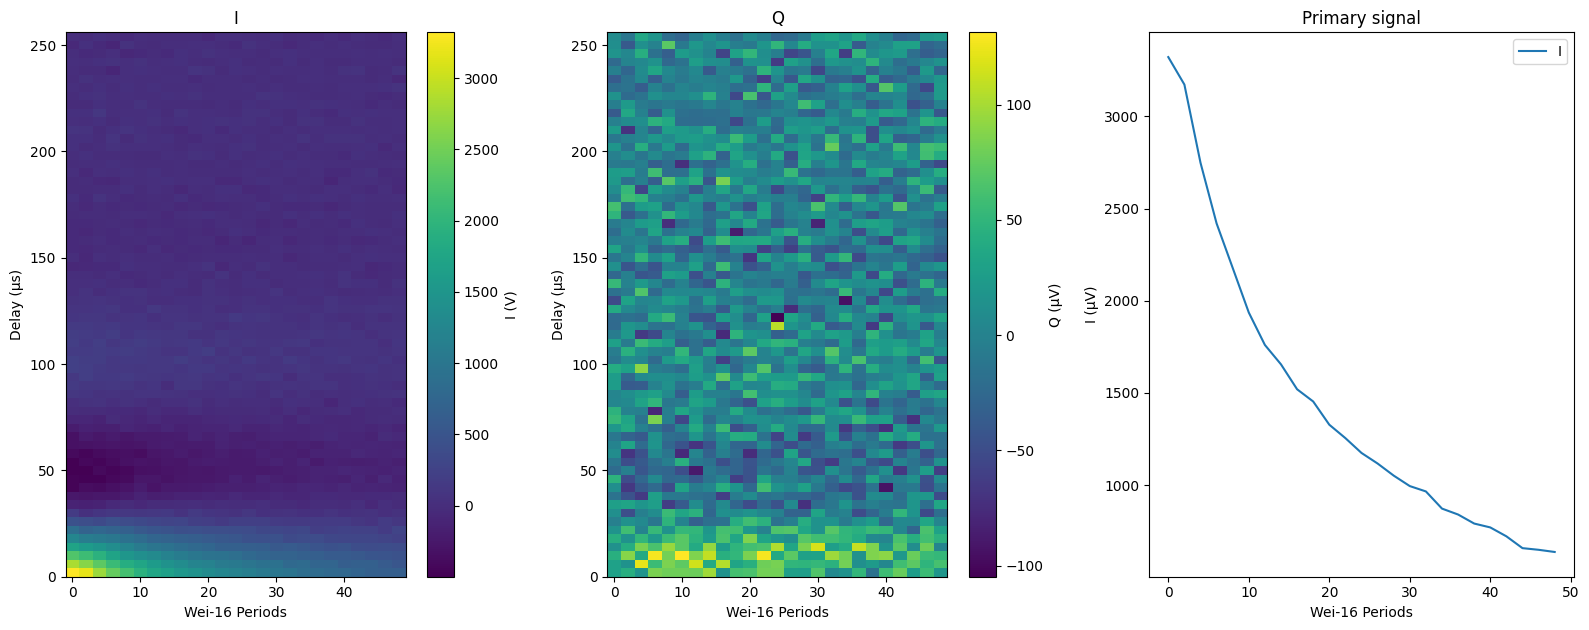

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.20s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.78s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.29s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0064
Experiment with c2=0 complete!



Testing c2=0.005 now.
5025.20064694 5004.18657028 4960.72196813 5044.88327311 5004.07204951 4960.93549202
2026-06-08 18:31:22,125 - qm - INFO     - Performing health check
2026-06-08 18:31:22,125 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:31:22,805 - qm - INFO     - Clearing queue
2026-06-08 18:31:22,805 - qm - INFO     - Adding program to queue.


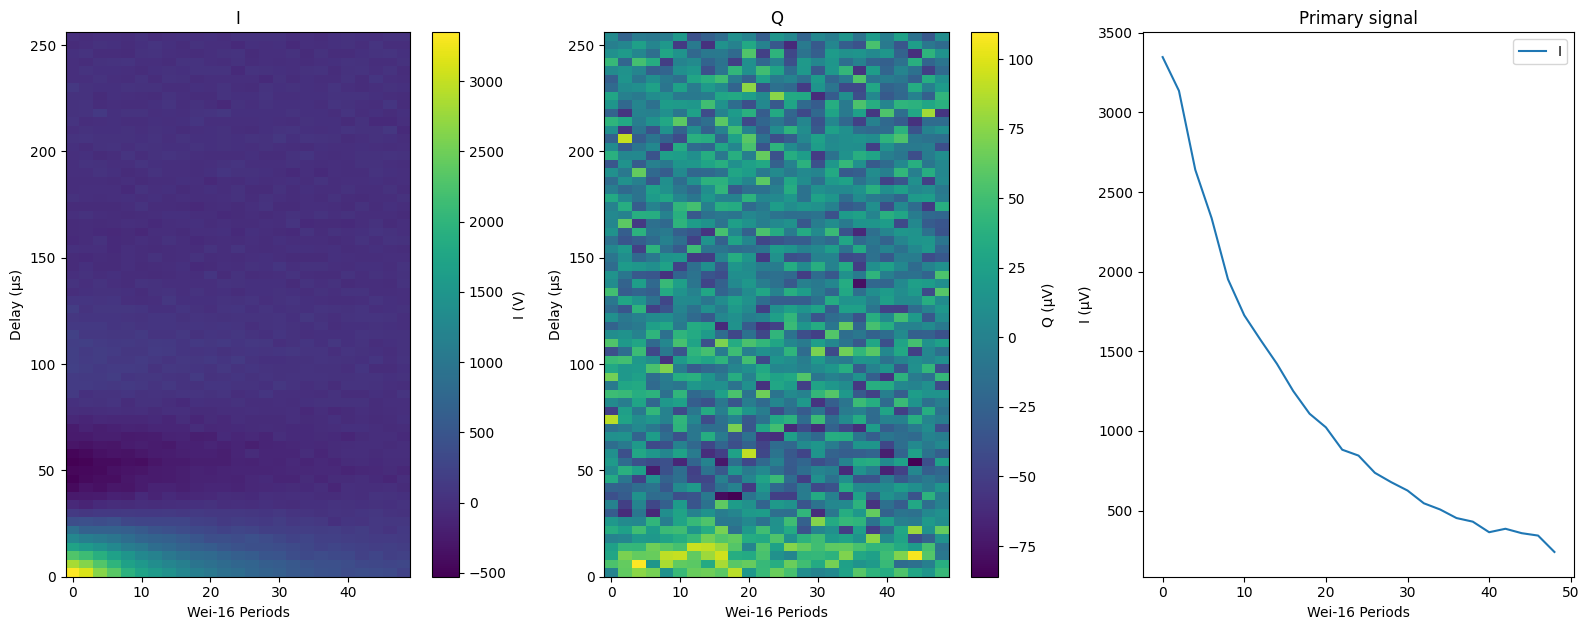

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.84s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.38s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0065
Experiment with c2=0.005 complete!



Testing c2=0.01 now.
5089.23527328 4981.10989311 4933.11767398 5080.97683431 4975.92900185 4939.63132346
2026-06-08 18:38:03,018 - qm - INFO     - Performing health check
2026-06-08 18:38:03,018 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:38:03,672 - qm - INFO     - Clearing queue
2026-06-08 18:38:03,688 - qm - INFO     - Adding program to queue.


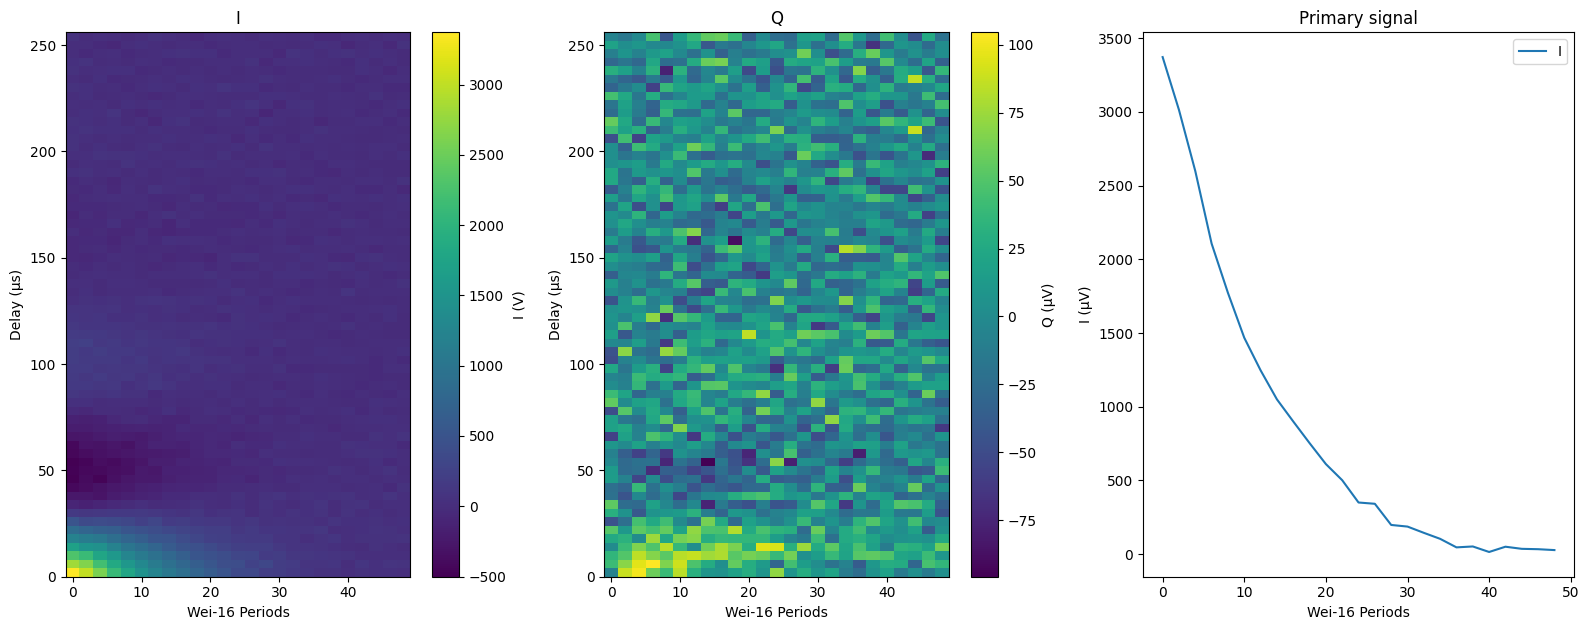

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.35s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.83s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.34s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0066
Experiment with c2=0.01 complete!



Testing c2=0.015 now.
5135.91707865 4958.16211016 4909.49978947 5135.10694532 4948.7993708 4912.51470561
2026-06-08 18:44:43,844 - qm - INFO     - Performing health check
2026-06-08 18:44:43,860 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:44:44,563 - qm - INFO     - Clearing queue
2026-06-08 18:44:44,579 - qm - INFO     - Adding program to queue.


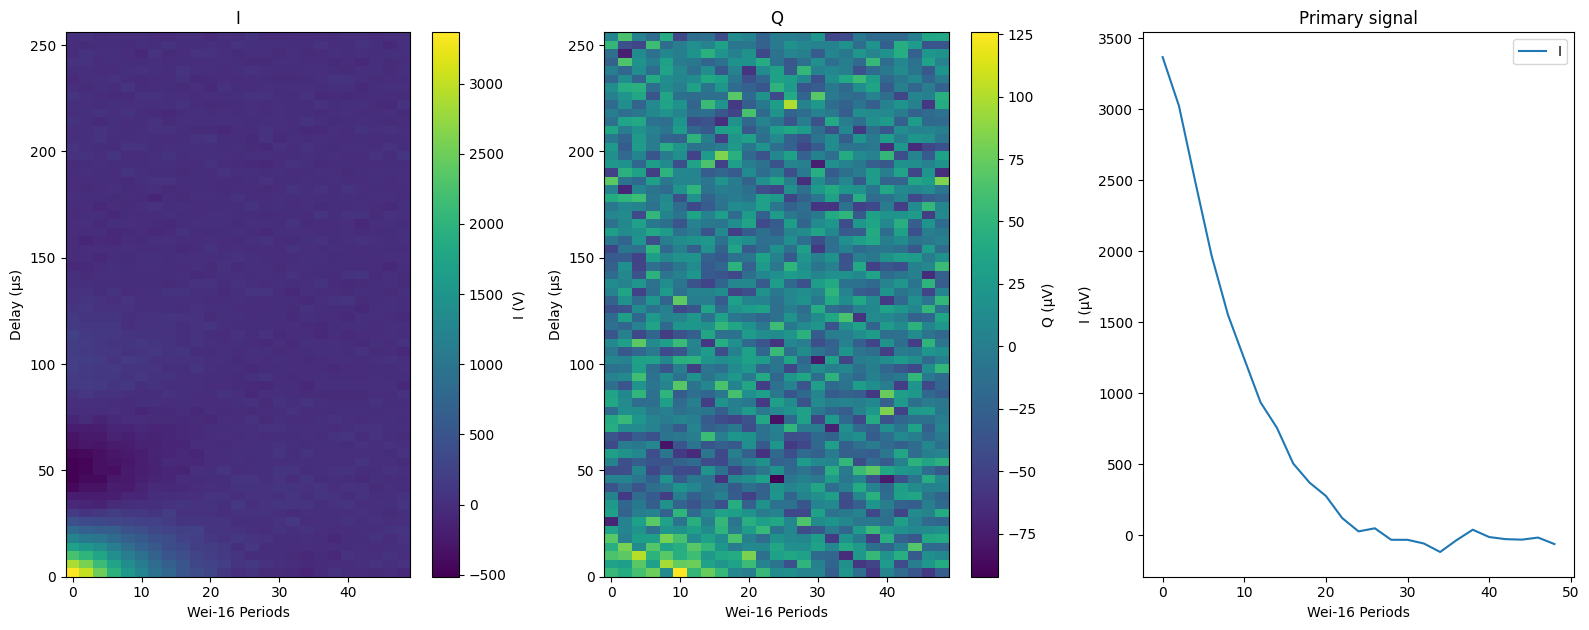

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.33s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.86s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.50s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0067
Experiment with c2=0.015 complete!



Testing c2=0.02 now.
5186.56554825 4930.91149195 4885.41807029 5185.44424656 4924.44499266 4887.2156503
2026-06-08 18:51:24,828 - qm - INFO     - Performing health check
2026-06-08 18:51:24,828 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:51:25,657 - qm - INFO     - Clearing queue
2026-06-08 18:51:25,672 - qm - INFO     - Adding program to queue.


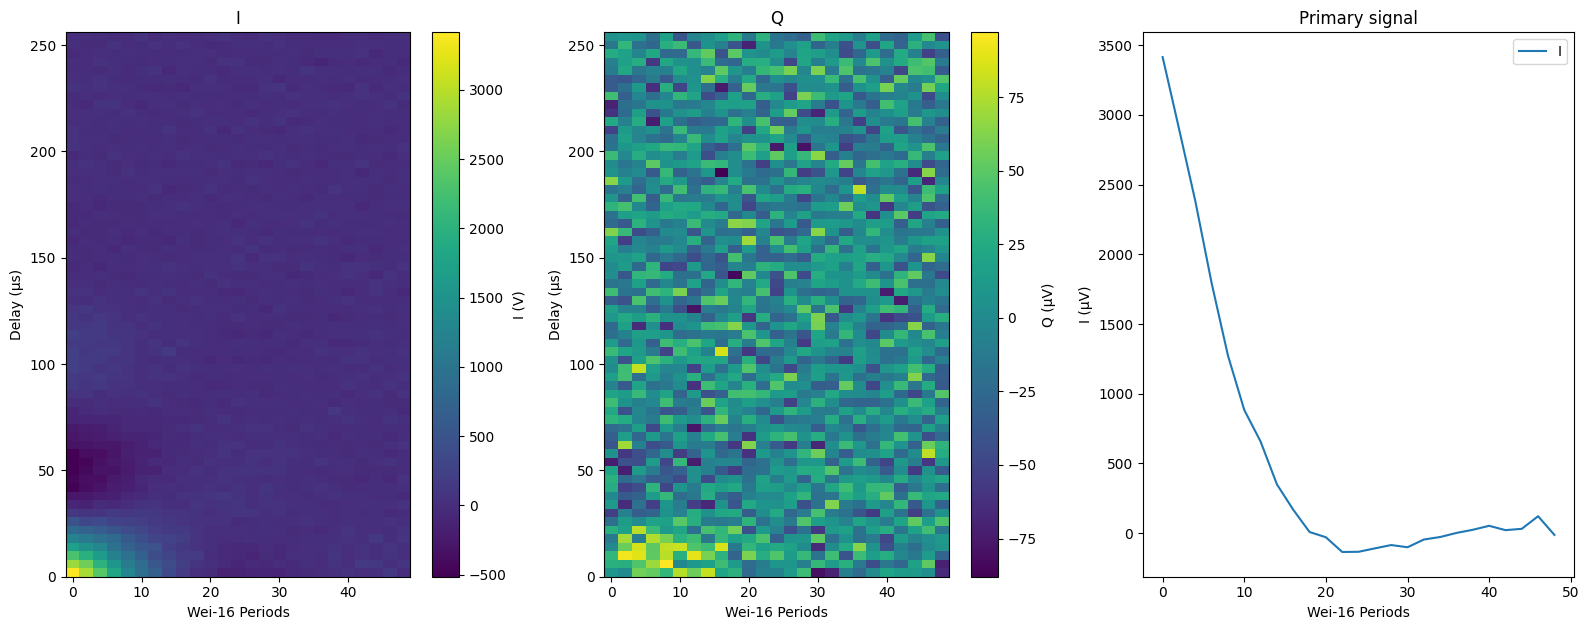

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.39s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.95s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0068
Experiment with c2=0.02 complete!



Testing c2=0.025 now.
5235.34556922 4905.02134313 4861.07455785 5236.32740936 4899.48739049 4862.74372995
2026-06-08 18:58:05,836 - qm - INFO     - Performing health check
2026-06-08 18:58:05,836 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 18:58:06,547 - qm - INFO     - Clearing queue
2026-06-08 18:58:06,547 - qm - INFO     - Adding program to queue.


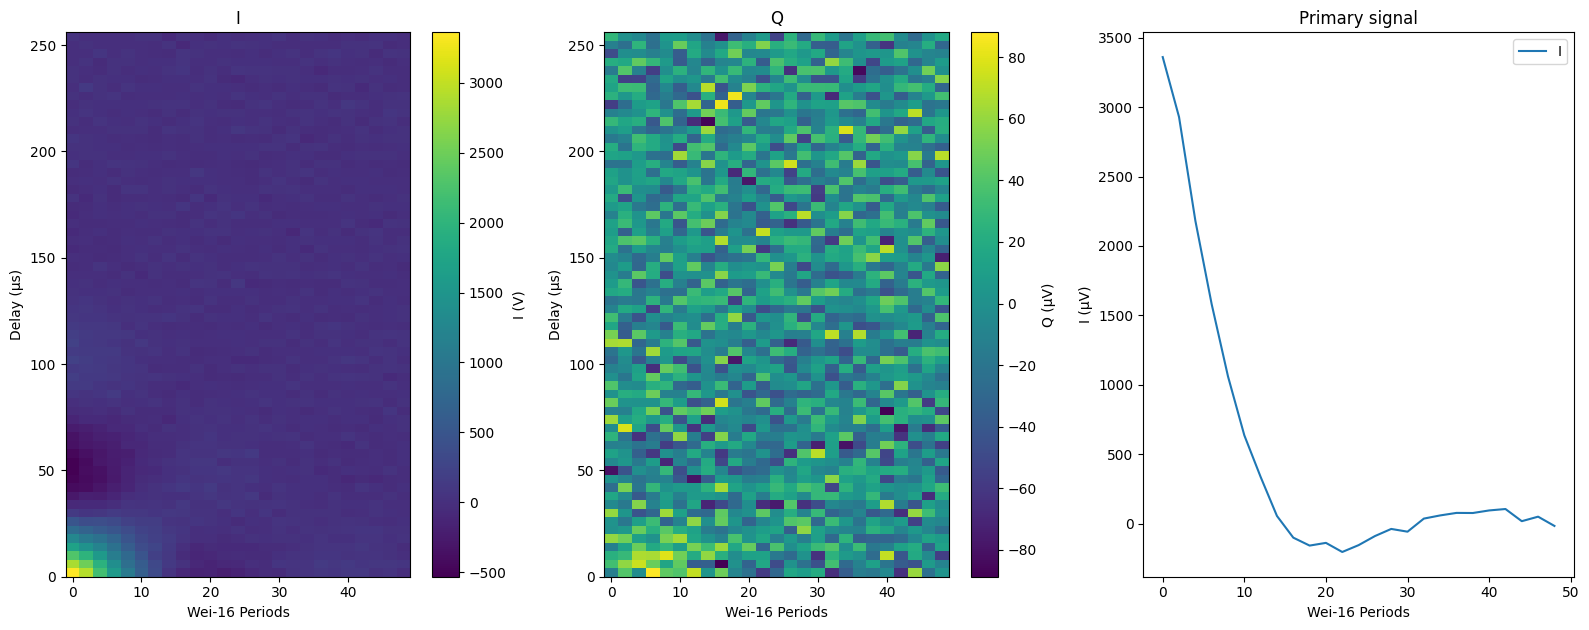

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.28s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.78s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.27s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0069
Experiment with c2=0.025 complete!





In [26]:
rho0 = "X" # whether to start in X or Z state for the experiment

for c2 in (-.025,-.02,-.015,-.01,-.005,0,.005,.01,.015,.02,.025):
    print("Testing c2=" + str(c2) + " now.")

    p1 = settings.pulse_length
    if c2 == -0.025: t1,t2,t3,t1p,t2p,t3p = [4733.8494314 ,5155.37471909,5111.60629594,4733.28251133,5157.88129102,5108.00575121]
    if c2 == -0.02:  t1,t2,t3,t1p,t2p,t3p = [4781.72295941,5132.24122359,5087.9152078 ,4785.86790744,5130.22648367,5082.02621808]
    if c2 == -0.015: t1,t2,t3,t1p,t2p,t3p = [4834.44272209,5106.44489723,5060.56232846,4833.91766161,5104.9902268 ,5059.6421638 ]
    if c2 == -0.01:  t1,t2,t3,t1p,t2p,t3p = [4882.29296006,5076.19341604,5029.13783319,4887.14815252,5084.30108528,5040.92655291]
    if c2 == -0.005: t1,t2,t3,t1p,t2p,t3p = [4926.3360118 ,5054.4866408 ,5010.67447744,4942.86759649,5055.40091762,5010.23435585]
    if c2 == 0:      t1,t2,t3,t1p,t2p,t3p = [4976.2371799 ,5029.73319242,4983.82085345,4993.31674266,5029.36891249,4987.52311908]
    if c2 == 0.005:  t1,t2,t3,t1p,t2p,t3p = [5025.20064694,5004.18657028,4960.72196813,5044.88327311,5004.07204951,4960.93549202]
    if c2 == 0.01:   t1,t2,t3,t1p,t2p,t3p = [5089.23527328,4981.10989311,4933.11767398,5080.97683431,4975.92900185,4939.63132346]
    if c2 == 0.015:  t1,t2,t3,t1p,t2p,t3p = [5135.91707865,4958.16211016,4909.49978947,5135.10694532,4948.7993708 ,4912.51470561]
    if c2 == 0.02:   t1,t2,t3,t1p,t2p,t3p = [5186.56554825,4930.91149195,4885.41807029,5185.44424656,4924.44499266,4887.2156503 ]
    if c2 == 0.025:  t1,t2,t3,t1p,t2p,t3p = [5235.34556922,4905.02134313,4861.07455785,5236.32740936,4899.48739049,4862.74372995]
    t1e = t1 + (p1/2) # start & end t1.
    print(t1, t2, t3, t1p, t2p, t3p)

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)
    expt.add_frame_change(angle=-3.75, elements=(settings.res_key, settings.helper_key))

    # rotate to evolve X, Y, or Z state operator
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases = np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
    period_list = np.arange(0,50,2)
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    
    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)
    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with c2=" + str(c2) + " complete!\n\n\n")

In [42]:
data_path = settings.save_dir / "experiment_0063/data.json"

with open(data_path, "r") as f:
    data_dict = json.load(f)

re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
c02signal = re[:, 0]

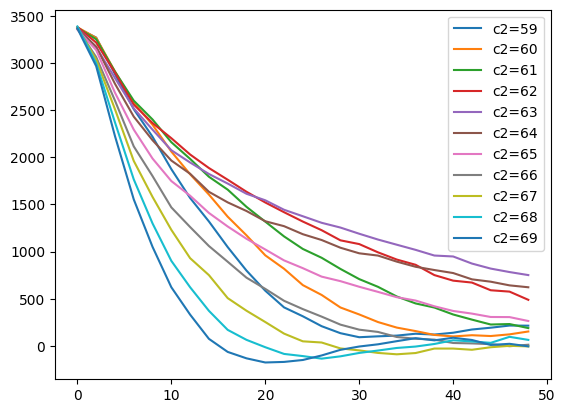

In [34]:
for exp_id in range (59,70) :
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    with open(data_path, "r") as f: data_dict = json.load(f)
    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    plt.plot(periods, re[:, 0], label="c2="+str(exp_id))
plt.legend()

[-0.    -0.005 -0.01  -0.015 -0.02  -0.025]
Exp 64 | c2=0.000 | A=1.199, b1=26.640, b2=-20.052, c=50.954, d=25.061, e=12.781
Exp 65 | c2=0.005 | A=1.199, b1=50.000, b2=-42.597, c=69.150, d=31.612, e=9.021
Exp 66 | c2=0.010 | A=1.200, b1=14.792, b2=-50.000, c=34.654, d=95.097, e=14.652
Exp 67 | c2=0.015 | A=1.067, b1=5.829, b2=-9.773, c=20.609, d=25.359, e=12.077
Exp 68 | c2=0.020 | A=1.015, b1=2.704, b2=-6.314, c=16.662, d=19.832, e=11.899
Exp 69 | c2=0.025 | A=1.010, b1=-0.384, b2=-4.491, c=15.586, d=28.851, e=22.739


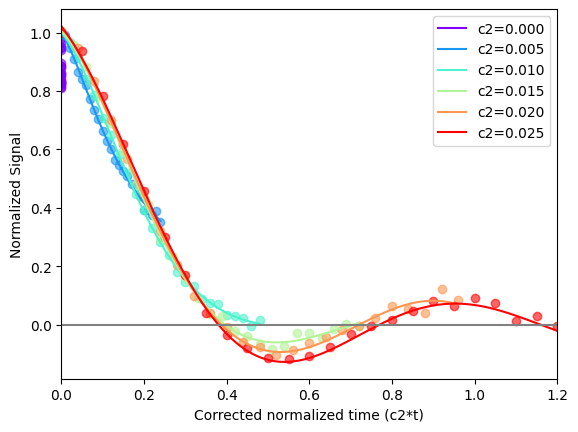

In [55]:
# ---- Gaussian Sinc fit function ----
def damped_moment(t, A, b1, b2, c, d, e):
    fid = A * np.sinc((t-b1)/c) * np.exp(((t-b2)/d)**2 / 2) * np.exp(-t / e)
    return np.array(fid, dtype=float)

# ---- Experiment range ----
exp_ids = list(range(64, 70))
c2_values = -1 * np.arange(0.00, 0.03, 0.005)
print(c2_values)

# ---- Colors (red → purple) ----
colors = plt.cm.rainbow(np.linspace(0, 1, len(exp_ids)))

plt.figure()

# ---- Loop over experiments ----
for i, exp_id in enumerate(exp_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    signal = re[:, 0] / c02signal

    # ---- Fit ----
    popt, _ = curve_fit(
        damped_moment,
        periods,
        signal,
        p0=[1.0, 0, 0, 10, 10, 1],
        bounds=([1, -50, -50, 0, 0, 0],[1.2, 50, 50, 1000, 10000, 9999999])
    )

    # ---- Fit curve ----
    x_fit = np.linspace(min(periods), max(periods), 500)
    y_fit = damped_moment(x_fit, *popt)

    # ---- Plot ----
    label = f"c2={-c2_values[i]:.3f}"
    plt.scatter(abs(c2_values[i]) * periods, signal, color=colors[i], alpha=0.6)
    plt.plot(abs(c2_values[i]) * x_fit, y_fit, color=colors[i], label=label)

    print(f"Exp {exp_id} | c2={abs(c2_values[i]):.3f} | "
          f"A={popt[0]:.3f}, b1={popt[1]:.3f}, b2={popt[2]:.3f}, c={popt[3]:.3f}, d={popt[4]:.3f}, e={popt[5]:.3f}")

# ---- Final plot formatting ----
plt.plot(periods, np.zeros_like(periods), color='gray')  # baseline
plt.legend()
plt.xlim(0, max(.025*periods))
plt.xlabel("Corrected normalized time (c2*t)")
plt.ylabel("Normalized Signal")

plt.show()

adjust pulse length/shape change pulse X to Y, angle, frame change
v-Δ, w+Δ

[-2.50000000e-02 -2.00000000e-02 -1.50000000e-02 -1.00000000e-02
 -5.00000000e-03  3.46944695e-18  5.00000000e-03  1.00000000e-02
  1.50000000e-02  2.00000000e-02  2.50000000e-02]


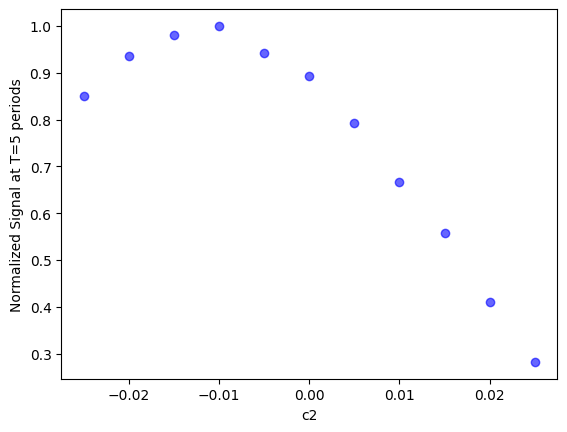

In [ ]:
# ---- Parabola fit function ----
def Parabola(t, A, t0, b):
    return A * (np.abs(t-t0)**2) + b


# ---- Experiment range ----
exp_ids = list(range(59, 70))
c2_values = np.arange(-0.025, 0.03, 0.005)  # -0.5 to 0.5
print(c2_values)

plt.figure()

T5signal = np.empty(len(exp_ids), dtype=float)

# ---- Loop over experiments ----
for i, exp_id in enumerate(exp_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    T5signal[i] = re[5,0]

plt.scatter(c2_values, T5signal/np.max(T5signal), color='blue', alpha=0.6)
plt.xlabel("c2")
plt.ylabel("Normalized Signal at T=5 periods")

# x_fit = np.linspace(min(c2_values), max(c2_values), 500)
# popt, pcov = curve_fit(Parabola, c2_values, T5signal, p0=[-2500.0, 0.2, 2500], maxfev=10000)
# y_fit = Parabola(x_fit, *popt)
# plt.plot(x_fit, Parabola(x_fit, *popt), color='red', label=f"Fit: A={popt[0]:.2f}, t0={popt[1]:.2f}, b={popt[2]:.2f}")
# plt.legend()

plt.show()

